1. 为什么需要多智能体系统？

1.1 单一 Agent 的局限性

问题：

❌ 一个 Agent 承担所有任务，职责不清

❌ Prompt 过于复杂，难以维护

❌ 无法实现专业化分工

❌ 难以复用和组合

示例：旅行规划

In [1]:
# 单一 Agent 需要处理所有事情
single_agent_prompt = """
你是一个旅行规划助手，需要：
搜索并推荐航班
搜索并推荐酒店
推荐当地活动
估算总预算
生成行程表
提供天气信息
提供签证信息
... （太多了！）
"""

1.2 多智能体的优势
解决方案：专业化分工

✅ 每个 Agent 专注一个领域

✅ Prompt 简单清晰

✅ 独立开发和测试

✅ 可复用和组合

示例：多 Agent 系统

旅行规划系统
├── 航班专家 Agent（专注航班搜索和推荐）
├── 酒店专家 Agent（专注酒店搜索和推荐）
├── 活动专家 Agent（专注当地活动推荐）
└── 协调器 Agent（整合信息，生成最终方案）

2. Subgraphs: 图中的图
2.1 什么是 Subgraph?
Subgraph（子图） 就是嵌套在主图中的一个完整的图：

子图本身是一个独立的 Graph

子图可以被当作一个节点在主图中使用

子图有自己的 State、Nodes、Edges

概念对比：

普通节点 = 一个函数
Subgraph = 一个完整的图（包含多个节点、边）

2.2 为什么使用 Subgraph?
优势：

✅ 模块化： 复杂逻辑封装成独立的子图

✅ 可复用： 同一个子图可以在多处使用

✅ 清晰： 主图保持简洁，细节在子图中

✅ 独立测试： 每个子图可以单独测试

2.3 基本示例

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

def display_graph(app):
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))

# === 子图 State ===
class SubGraphState(TypedDict):
    number: int       # 与主图共享的 key
    result: int

# === 子图节点 ===
def sub_step1(state: SubGraphState) -> dict:
    """子步骤 1"""
    return {"result": state["number"] * 2}

def sub_step2(state: SubGraphState) -> dict:
    """子步骤 2"""
    return {"result": state["result"] + 10}

# === 创建子图 ===
sub_graph = StateGraph(SubGraphState)
sub_graph.add_node("step1", sub_step1)
sub_graph.add_node("step2", sub_step2)
sub_graph.add_edge(START, "step1")
sub_graph.add_edge("step1", "step2")
sub_graph.add_edge("step2", END)

sub_graph_compiled = sub_graph.compile()

# === 主图 State ===
class MainState(TypedDict):
    number: int        # 与子图共享 → 自动传入子图
    result: int        # 与子图共享 → 自动从子图传回
    final_result: int

# === 主图节点 ===
def prepare_input(state: MainState) -> dict:
    """准备输入"""
    return {"number": state["number"]}

def collect_result(state: MainState) -> dict:
    """收集子图结果"""
    return {"final_result": state["result"]}

# === 创建主图（子图直接作为节点） ===
main_graph = StateGraph(MainState)
main_graph.add_node("prepare", prepare_input)
main_graph.add_node("process", sub_graph_compiled)  # ✅ 直接添加编译后的子图（而非包装函数）
main_graph.add_node("collect", collect_result)

main_graph.add_edge(START, "prepare")
main_graph.add_edge("prepare", "process")
main_graph.add_edge("process", "collect")
main_graph.add_edge("collect", END)

main_app = main_graph.compile()

# === 测试 ===
result = main_app.invoke({"number": 5, "result": 0, "final_result": 0})
print(f"输入: 5")
print(f"子图处理: 5 * 2 + 10 = {result['final_result']}")  # 20

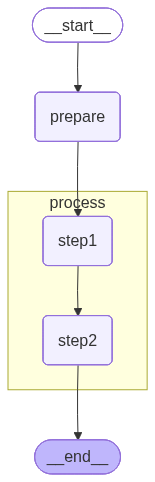

In [6]:
from IPython.display import Image, display

def display_graph(app):
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))  # xray=True 展开子图细节

display_graph(main_app)

2.4 State 映射
问题：主图和子图的 State 通常不同，如何传递数据？

解决方案：State 映射函数